Импортируем необходимые библиотеки и подключим базу данных, скопируем данные

In [ ]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

from pymorphy3 import MorphAnalyzer

import re
import nltk
from nltk.corpus import stopwords

conn = sqlite3.connect(r"C:\Users\Александр\Desktop\primpress.db")
df = pd.read_sql_query("SELECT * FROM articles;", conn)
conn.close()

print(df.head())

df.info()

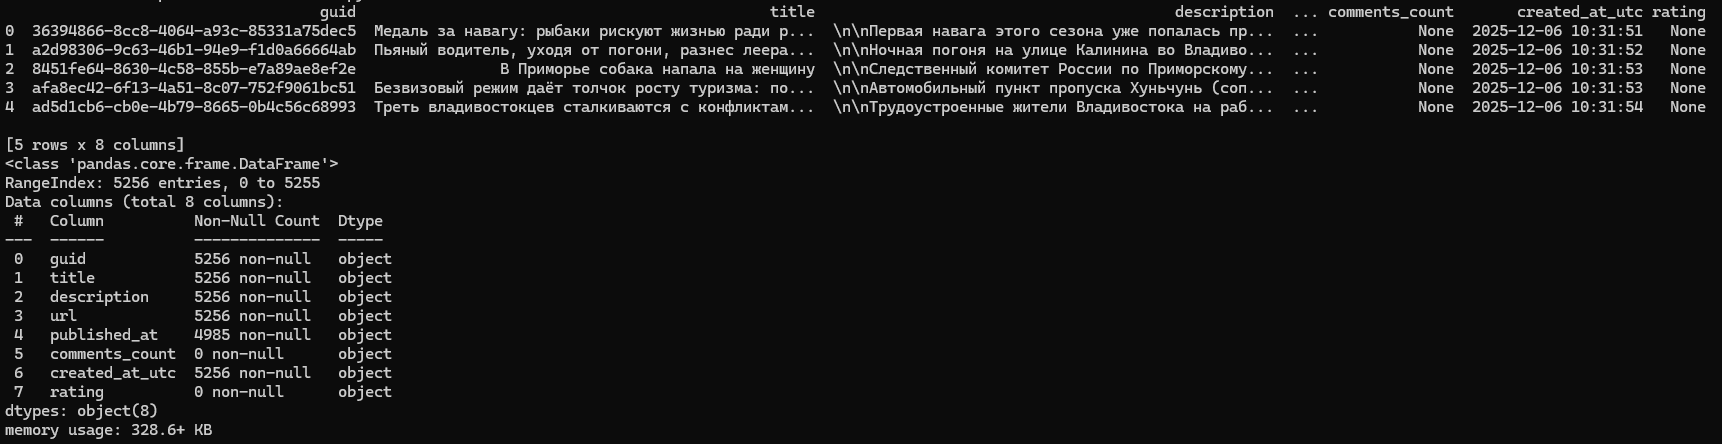

Приведём строковые даты к datetime

In [ ]:
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
df["created_at_utc"] = pd.to_datetime(df["created_at_utc"], errors="coerce")

print(df[["published_at", "created_at_utc"]].head())

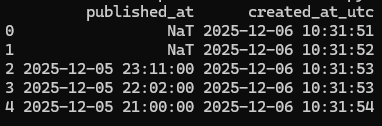

Загрузим стоп-слова

In [ ]:
nltk.download("stopwords")

Инициализируем морфоанализатор, список стоп слов и функцию для обработки текста. Выведем первый текст из базы данных и обработаем его с помощью функции.

In [ ]:
morph = MorphAnalyzer()
RUSSIAN_STOPWORDS = set(stopwords.words("russian"))

TOKEN_RE = re.compile(r"[А-Яа-яA-Za-z]+", flags=re.U)

def preprocess_text(text: str):

    if not isinstance(text, str):
        text = "" if text is None else str(text)

    text = text.lower()
    tokens = TOKEN_RE.findall(text)

    lemmas = []
    for token in tokens:

        if len(token) <= 2:
            continue


        if re.match(r"[а-я]", token):

            if token in RUSSIAN_STOPWORDS:
                continue
            parsed = morph.parse(token)[0]
            lemma = parsed.normal_form
            if lemma in RUSSIAN_STOPWORDS:
                continue
        else:

            lemma = token

        lemmas.append(lemma)

    return lemmas

sample_text = df["description"].iloc[0]
print(sample_text[:100], "...")

print(preprocess_text(sample_text)[:100])

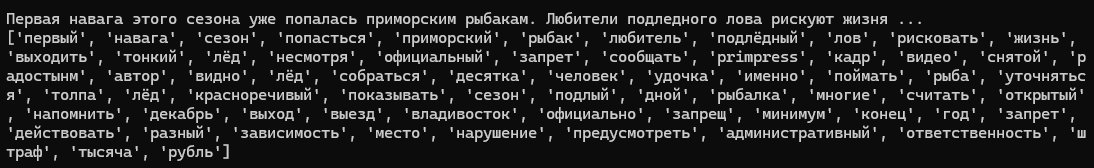

Теперь лемматизируем все тексты

In [ ]:
N_DOCS = len(df)

texts = df["description"].iloc[:N_DOCS].tolist()

tokenized_texts = [preprocess_text(t) for t in texts]

Обучим модель Word2Vec и проверим её на нескольких словах

In [ ]:
w2v = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10,
)

for test_word in ["икра", "остров", "проспект", "улица"]:
    if test_word not in w2v.wv:
        continue

    print(f"\nПохожие слова для «{test_word}»:")
    for word, score in w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")

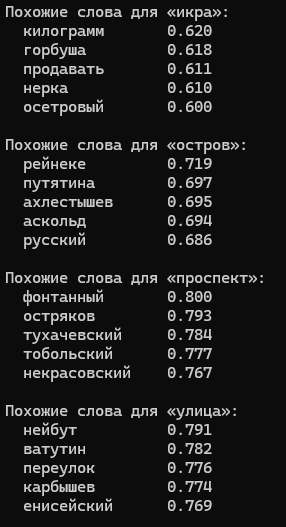

Получим список векторов документов

In [ ]:
def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

doc_vectors = np.vstack([doc_vector(t, w2v) for t in tokenized_texts])

Снизим размерность векторов с помощью PCA

In [ ]:
pca = PCA(n_components=2, random_state=42)

doc_vectors_2d = pca.fit_transform(doc_vectors)

df_subset = df.iloc[:N_DOCS].copy()
df_subset["pca_x"] = doc_vectors_2d[:, 0]
df_subset["pca_y"] = doc_vectors_2d[:, 1]

In [ ]:
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_for_dbscan)
distances, indices = neigh.kneighbors(X_for_dbscan)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance график (k={k})")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.grid(True)
plt.show()

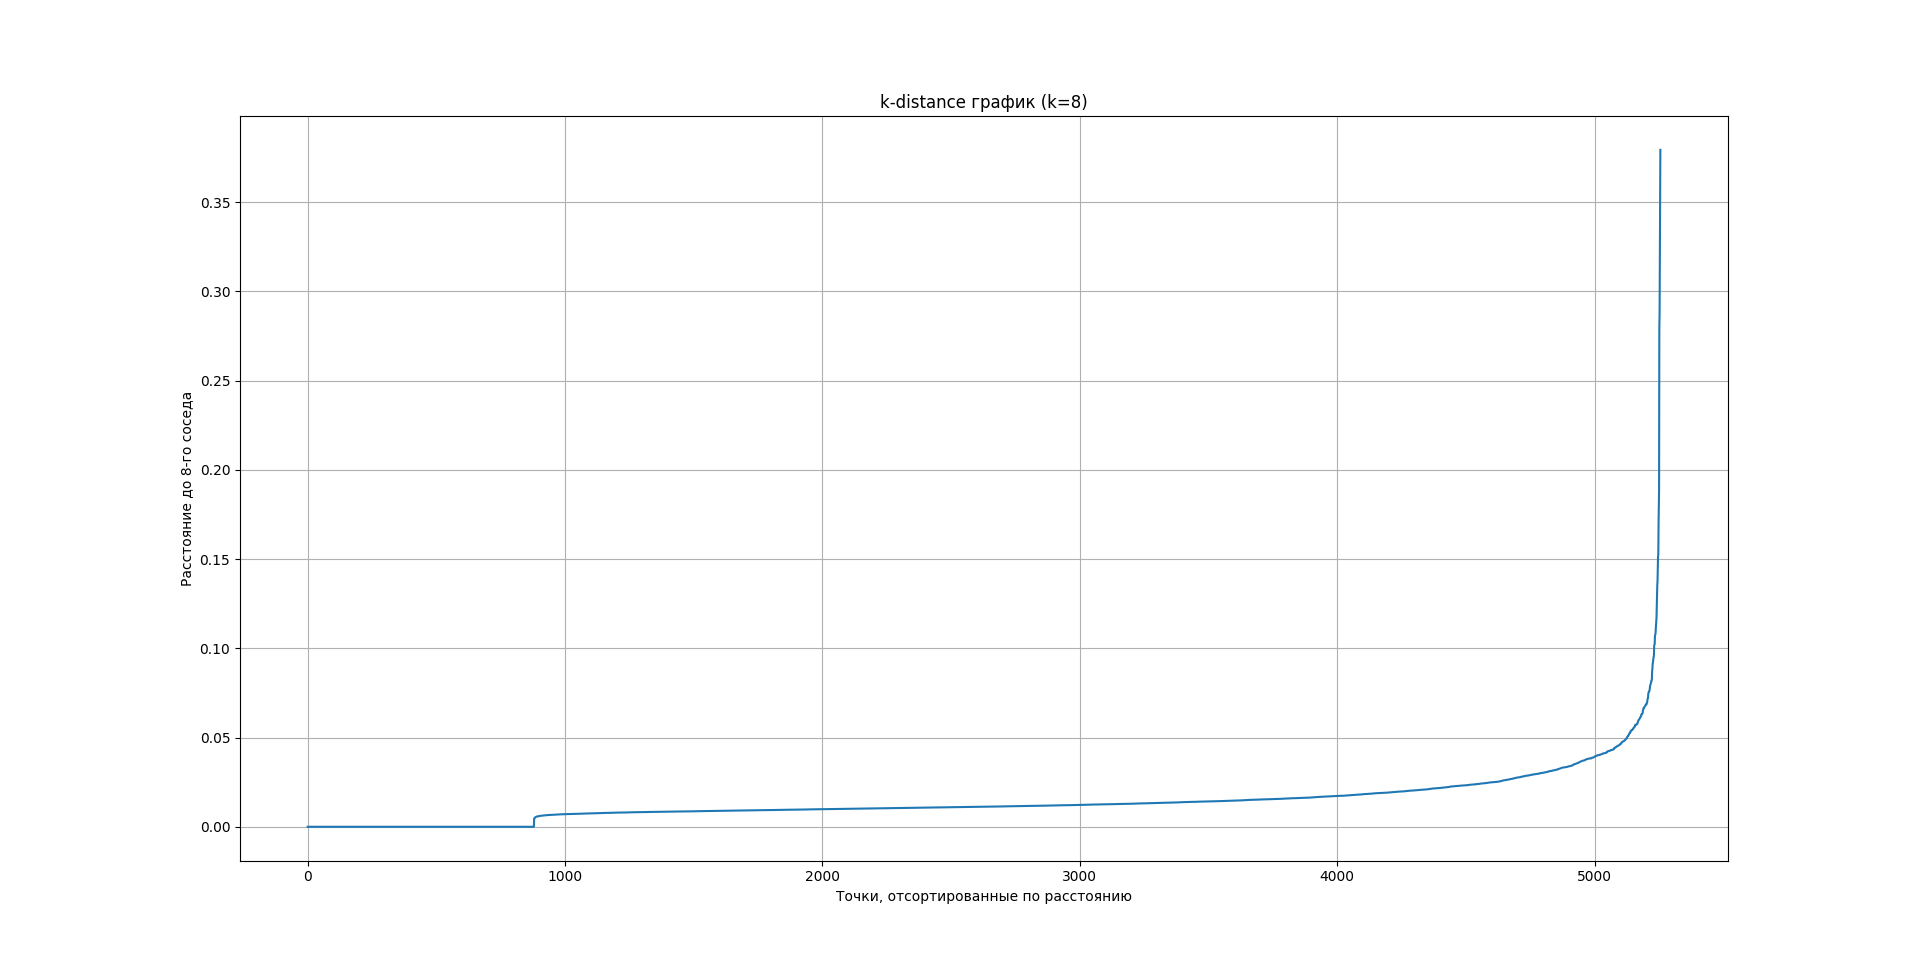

Обучим DBSCAN, добавим метку кластера в датафрейм и посмотрим пример

In [ ]:
dbscan = DBSCAN(eps=0.010, min_samples=8)

cluster_labels = dbscan.fit_predict(doc_vectors_2d)

df_subset["cluster"] = cluster_labels
print(df_subset[["title", "cluster"]].head(10))

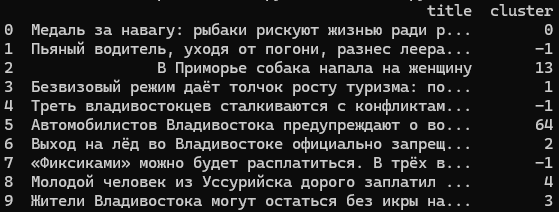

Визуализируем кластеры

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_subset["pca_x"],
    df_subset["pca_y"],
    c=df_subset["cluster"],
    s=6,
    cmap="tab10",
    alpha=0.7,
)
plt.colorbar(scatter, label="Cluster ID")
plt.title("Кластеры документов (PCA + DBSCAN)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

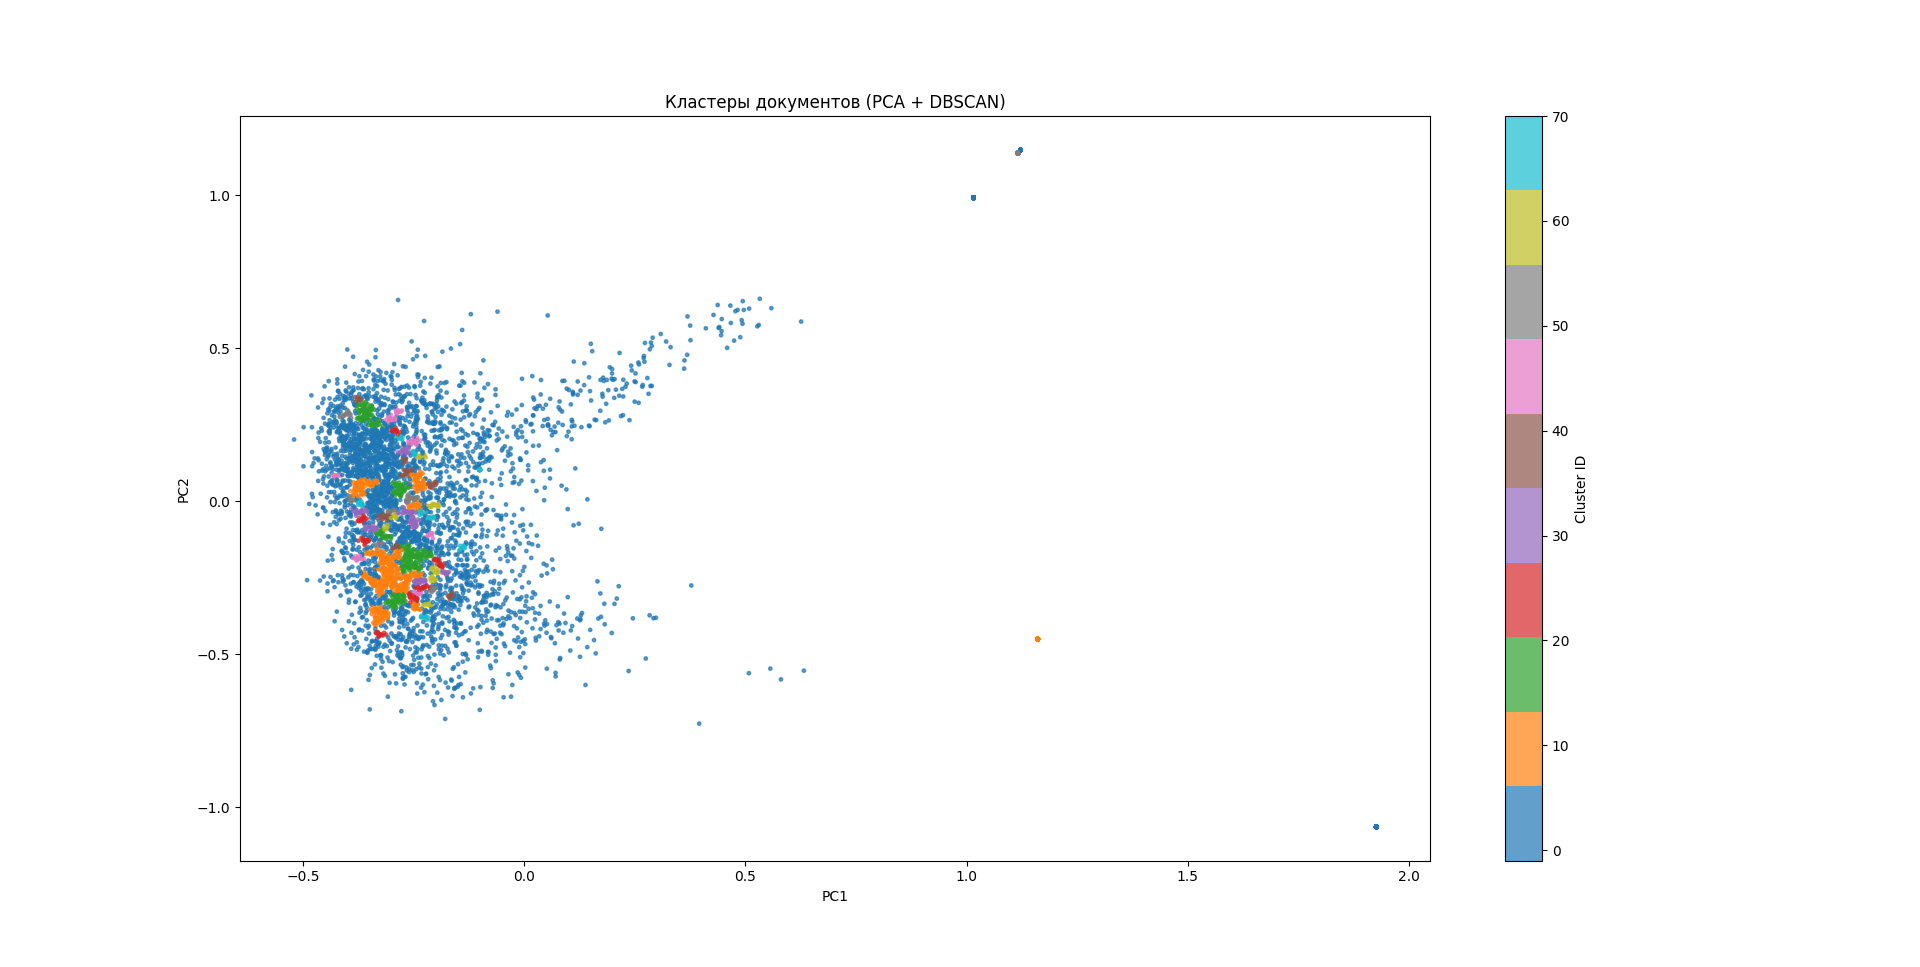

Оставляем только те объекты, которые отнесены к какому либо кластеру и создадим матрицу признаков X. Разделим выьорку на обучающую и тестовую.

In [ ]:
mask_non_noise = df_subset["cluster"] != -1
df_sup = df_subset[mask_non_noise].copy()

print(
    "Всего объектов для supervised-задачи:",
    len(df_sup),
    "из",
    len(df_subset),
)

idx = df_sup.index.to_numpy()

y = df_sup["cluster"].astype(int)

y.value_counts().sort_index()

doc_vectors_sup = doc_vectors[idx]

X = np.hstack([doc_vectors_sup])
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(X_train.shape, X_test.shape)

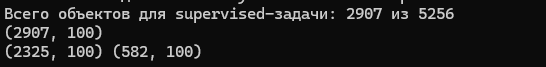

Обучим модель Decision Tree:

In [ ]:
dt_clf = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
)


dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

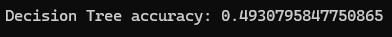

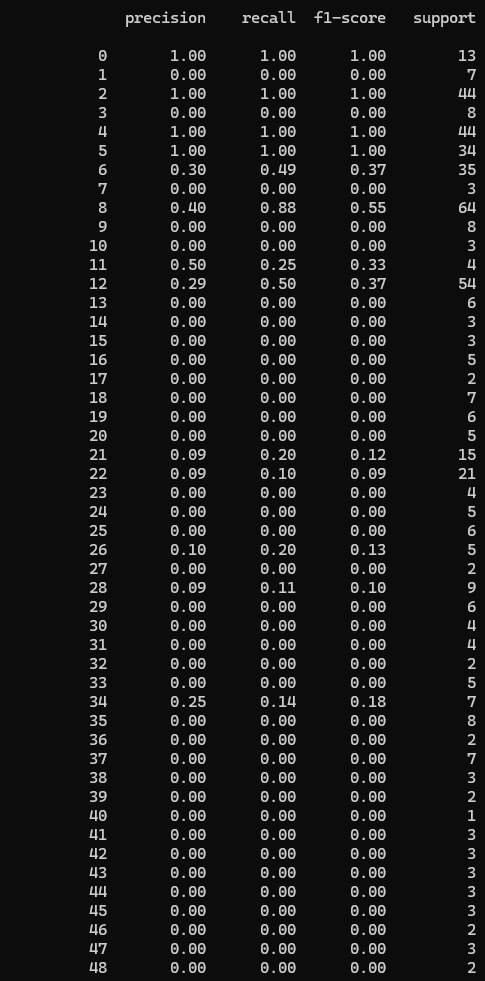

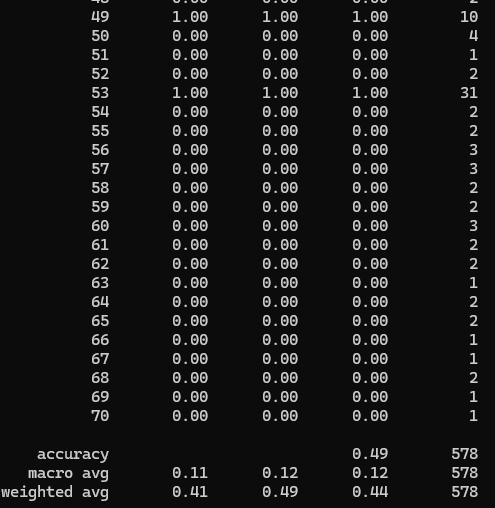

Подберём параметры KNN через GridSearchCV:

In [ ]:
knn_base = KNeighborsClassifier()

# Сетка гиперпараметров для перебора
param_grid = {
    "n_neighbors": [3, 5, 10, 15, 25],
    "weights": ["uniform", "distance"],
    "metric": ["cosine", "euclidean"],
}

grid_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,          # 5-fold cross-validation
    n_jobs=-1,     # использовать все доступные ядра
    verbose=1,     # чтобы видеть прогресс
)


grid_knn.fit(X_train, y_train)

print("Лучшие параметры:", grid_knn.best_params_)
print("Лучший CV accuracy:", grid_knn.best_score_)

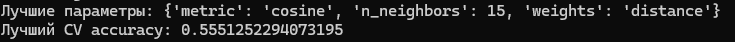

Используем найденный лучший классификатор и оценим его на тестовой выборке:

In [ ]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("k-NN (best) accuracy на тесте:", accuracy_score(y_test, y_pred_knn))
print("\nClassification report (k-NN best):")
print(classification_report(y_test, y_pred_knn))

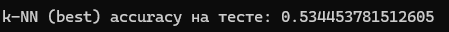

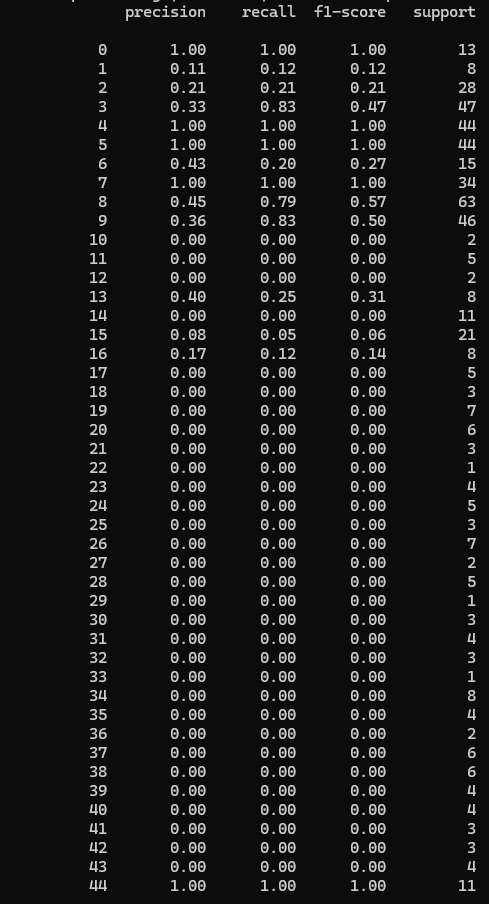

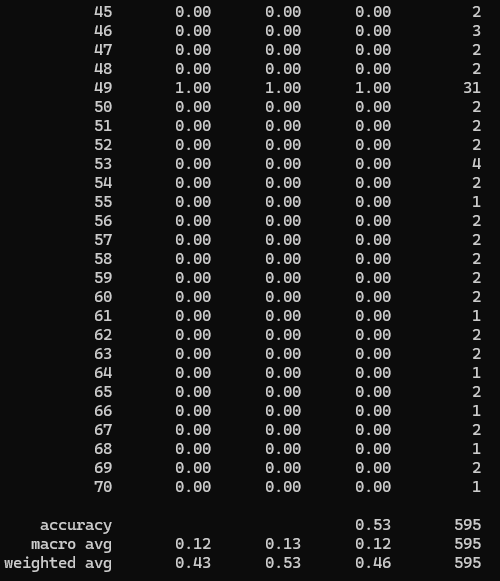